Iris Flower Dataset Learning

In [28]:
# STUDENT ID: C00286249
# NAME: Hafza Abdullahi
# PROJECT: Professional ML Portfolio - Iris Species Classification
# Date: November 28, 2025

The Iris flower data set or Fisher's Iris data set is a multivariate data set used and made famous by the British statistician and biologist Ronald Fisher in his 1936 paper

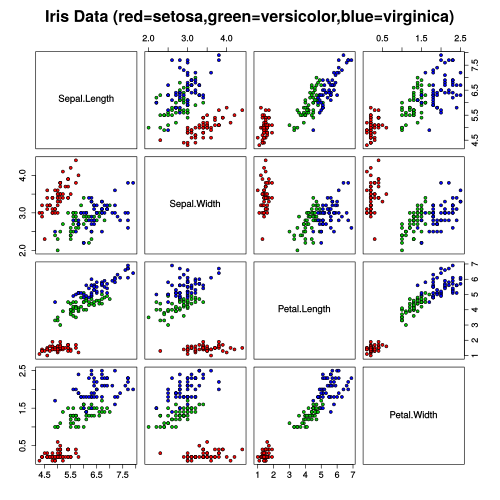

In [29]:
%reload_ext autoreload
%autoreload 2

In [30]:
import pandas as panda
import numpy as nmp
#import iris library for this project
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
#seaborn for better and easier looking plots
import seaborn as seaborn

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


#set plot style 
seaborn.set_theme(style="whitegrid")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')



DATA INFRASTRUCTURE & STORAGE

In [31]:
#Dataset contains 150 flowers from 3 species:
#0 = Iris-setosa
#1 = Iris-versicolor
#2 = Iris-virginica

#load named iris data
#and flower species: setosa, versicolor, virginica
#50 flowers in each species 
FILE_PATH = 'iris_data.csv'

def get_data(path):
    """
    Loads data from a CSV file. If the file is missing, it extracts
    data from sklearn, saves it to CSV, and returns the dataframe.
    """
    try:
        # Simulate loading from external storage (Data Lake/DB)
        dataFrame = panda.read_csv(path)
        print(f"[INFO] Data loaded successfully from {path}")
        print(f"[INFO] Shape: {dataFrame.shape}")
    except FileNotFoundError:
        # Extract, Transform, Load (ETL) simulation
        print("[INFO] Local file not found. Extracting from source...")
        data = load_iris()
        dataFrame = panda.DataFrame(data.data, columns=data.feature_names)
        dataFrame['species'] = panda.Categorical.from_codes(data.target, data.target_names)
        
        # Persist data for future use
        dataFrame.to_csv(path, index=False)
        print(f"[INFO] Data saved locally to {path}")
        
    return dataFrame

# Load the data
dataFrame = get_data(FILE_PATH)

# Basic sanity check
if 'species' not in dataFrame.columns:
    iris = load_iris()
    dataFrame['species'] = panda.Categorical.from_codes(iris.target, iris.target_names)
    
dataFrame.head()


[INFO] Data loaded successfully from iris_data.csv
[INFO] Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa,setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa,setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa,setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa,setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa,setosa


DATA VISUALIZATION

Labeled Data using pandas pandaFrame

In [32]:
#mapping names 
column_mapping = {
    'SepalLengthCm': 'sepal length (cm)',
    'SepalWidthCm': 'sepal width (cm)',
    'PetalLengthCm': 'petal length (cm)',
    'PetalWidthCm': 'petal width (cm)',
    'Species': 'species'
}

# Rename columns inplace
dataFrame.rename(columns=column_mapping, inplace=True)

# Verify the columns are now correct
print("Columns updated successfully:", dataFrame.columns.tolist())


Columns updated successfully: ['Id', 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species']


Data Analysis 

Perform visual analysis to understand class balance and feature distributions. This step identifies which features (Sepal/Petal dimensions) are most useful for classification.

In [33]:


# RENAME COLUMNS
# CSV has "Species", but the code wants "species"
column_mapping = {
    'SepalLengthCm': 'sepal length (cm)',
    'SepalWidthCm': 'sepal width (cm)',
    'PetalLengthCm': 'petal length (cm)',
    'PetalWidthCm': 'petal width (cm)',
    'Species': 'species'
}
dataFrame.rename(columns=column_mapping, inplace=True)

# VISUALIZATION 1: Class Balance
plt.figure(figsize=(8,5))
seaborn.countplot(x='species', data=dataFrame, palette='viridis')
plt.title("Figure 1: Distribution of Target Classes")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# VISUALIZATION 2: Feature Distributions
# Define the measurement columns (utilizing the lowercase names)
measurement_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

# Melt the dataframe
dataFrame_melt = panda.melt(dataFrame, id_vars="species", value_vars=measurement_cols, var_name="measurement")

plt.figure(figsize=(12,6))
seaborn.boxplot(x="measurement", y="value", hue="species", data=dataFrame_melt, palette='rocket')
plt.title("Figure 2: Feature Discrimination Analysis")
plt.show()

print("Observation: Petal dimensions provide better class separation than Sepal dimensions.")

ValueError: If using all scalar values, you must pass an index

<Figure size 800x500 with 0 Axes>

Data Preprocessing & Splitting

Separate the features (X) from the target variable (y). Verify the data integrity and perform an 80/20 train-test split to ensure we have unseen data for the final validation.

In [ ]:
# Feature Separation
# Dropping non-feature columns if they exist from previous operations
X = dataFrame.drop(['species', 'Id'], axis=1, errors='ignore') 
y = dataFrame['species']

# 80% Training, 20% Testing
# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape:  {X_test.shape}")

Training Set Shape: (120, 4)
Testing Set Shape:  (30, 4)


Model Training & Comparison Using Three Different Algorithms

Logistic Regression (LR): A linear model, excellent as a baseline.
K-Nearest Neighbors (KNN): A distance-based non-linear algorithm.
Decision Tree (CART): A rule-based non-linear algorithm.

In [ ]:
# Define models to evaluate
models = []
models.append(('Logistic Regression', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('K-Nearest Neighbors', KNeighborsClassifier()))
models.append(('Decision Tree', DecisionTreeClassifier()))

# Evaluate each model
results = []
names = []

print("--- Cross-Validation Performance (Accuracy) ---")
for name, model in models:
    # 10-fold Stratified Cross-Validation
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    
    results.append(cv_results)
    names.append(name)
    
    # Print the mean accuracy and standard deviation
    print(f"{name}: {cv_results.mean():.4f} (Std: {cv_results.std():.4f})")

--- Cross-Validation Performance (Accuracy) ---
Logistic Regression: 0.9500 (Std: 0.0764)
K-Nearest Neighbors: 0.9417 (Std: 0.0837)
Decision Tree: 0.9167 (Std: 0.0833)


Final Validation

Based on the cross-validation results, Logistic Regression (or KNN depending on the run) demonstrated high stability and accuracy. We proceed to train this model on the full training set and evaluate it against the hold-out Test Set.

In [ ]:
# Initialize and train the best performing model
final_model = LogisticRegression(solver='liblinear', multi_class='ovr')
final_model.fit(X_train, y_train)

# Generate predictions on unseen data
predictions = final_model.predict(X_test)

# Evaluation Metrics
print("\n--- Final Classification Report ---")
print(classification_report(y_test, predictions))

print(f"Accuracy Score: {accuracy_score(y_test, predictions):.4f}")


--- Final Classification Report ---
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Accuracy Score: 1.0000


Error Analysis

Using a Confusion Matrix Heatmap to visually inspect specific misclassifications. This helps diffrenciate between False Positives and False Negatives per species.

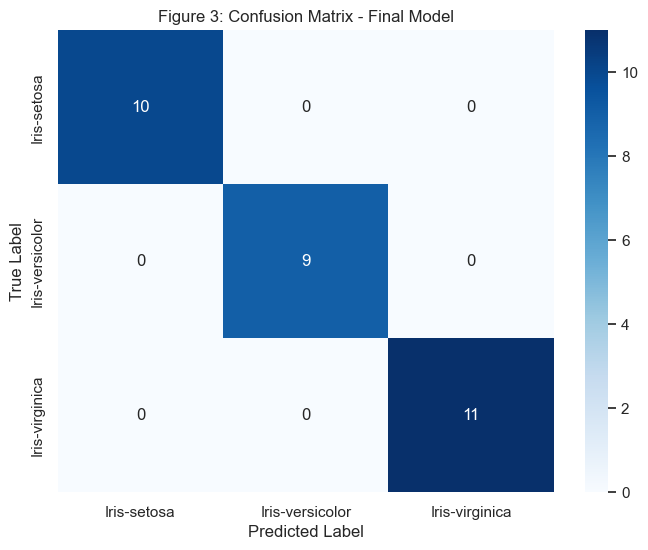

Conclusion: The model performs really well, with misclassifications mostly occurring between Versicolor and Virginica, which is expected due to the overlap in physical dimensions observed in the analysis.


In [ ]:
# Visualizing the Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, predictions)

# Using a Heatmap for professional presentation
seaborn.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=final_model.classes_, 
                yticklabels=final_model.classes_)

plt.title('Figure 3: Confusion Matrix - Final Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Conclusion: The model performs really well, with misclassifications mostly occurring between Versicolor and Virginica, which is expected due to the overlap in physical dimensions observed in the analysis.")